## Project 1

### Part A

In [35]:
import pandas as pd
# Code part A
# Taking the 10 year averaged datasets for offshore wind, onshore wind and pv

offshore_wind_cf = pd.read_csv("../data/averaged_offshore_wind_capacity_factor_denmark_hourly.csv", index_col=0)
onshore_wind_cf = pd.read_csv("../data/averaged_onshore_wind_capacity_factor_denmark_hourly.csv", index_col=0)
pv_cf = pd.read_csv("../data/averaged_pv_capacity_factor_denmark_hourly.csv", index_col=0)
demand = pd.read_csv("../data/denmark_demand.csv", index_col=0)

pv = pv_cf.rename(columns={"cf": "pv_cf"})
onshore = onshore_wind_cf.rename(columns={"cf": "onshore_cf"})
offshore = offshore_wind_cf.rename(columns={"cf": "offshore_cf"})

work_df = pd.concat([pv, onshore, offshore, demand], axis=1)
work_df.index = pd.to_datetime(
    "2015/" + work_df.index.astype(str),
    format="%Y/%d/%m %H:%M"
)

In [36]:
# Annualised capital costs
annualised_offshore_wind_capex = 101644 # EUR/MW/year PLACEHOLDER
annualised_onshore_wind_capex = 101644 # EUR/MW/year PLACEHOLDER
annualised_pv_capex = 51346 # EUR/MW/year PLACEHOLDER
annualised_battery_inverter_capex = 0 # EUR/MW/year PLACEHOLDER
annualised_battery_energy_capex = 0 # EUR/MWh/year PLACEHOLDER

# Annual OPEX costs
offshore_wind_opex = 0 # EUR/MW/year PLACEHOLDER
onshore_wind_opex = 0 # EUR/MW/year PLACEHOLDER
pv_opex = 0 # EUR/MW/year PLACEHOLDER
battery_opex = 0 # EUR/MW/year PLACEHOLDER

# Setting up marginal generation costs
onshore_wind_marginal_cost = 0 # EUR/MWh PLACEHOLDER
offshore_wind_marginal_cost = 0 # EUR/MWh PLACEHOLDER
pv_marginal_cost = 0 # EUR/MWh PLACEHOLDER

# Battery energy-to-power ratio
battery_hours = 2

# Efficiencies
battery_inverter_efficiency = 0.96

In [40]:
# Building the model

import linopy
import matplotlib.pyplot as plt

# Create model instance
m = linopy.Model()

# Take time index to use as a time coordiante (this is a timeseries)
T = work_df.index

# Take capacity factors of technologies
cf_pv = work_df["pv_cf"]
cf_off_wind = work_df["offshore_cf"]
cf_on_wind = work_df["onshore_cf"]
demand = work_df["demand"]

# Add capacity variable (MW)
K_pv   = m.add_variables(lower=0, name="K_pv")
K_offshore_wind = m.add_variables(lower=0, name="K_offshore_wind")
K_onshore_wind = m.add_variables(lower=0, name="K_onshore_wind")
K_battery = m.add_variables(lower=0, name="K_battery")

# Battery energy capacity (MWh)
E_bat = m.add_variables(lower=0, name="E_bat")

# Add dispatch variables (MW) over time
g_pv   = m.add_variables(lower=0, coords=[T], name="g_pv")
g_offshore_wind = m.add_variables(lower=0, coords=[T], name="g_offshore_wind")
g_onshore_wind = m.add_variables(lower=0, coords=[T], name="g_onshore_wind")

# Battery charge/discharge power (MW)
p_charge  = m.add_variables(lower=0, coords=[T], name="p_charge")
p_discharge = m.add_variables(lower=0, coords=[T], name="p_discharge")

# State of charge (MWh)
soc = m.add_variables(lower=0, coords=[T], name="soc")

# Add constraint that g_pv (dispatch at given time) can't be more than capacity * capacity factor
m.add_constraints(g_pv <= K_pv * cf_pv, name="pv_cf_limit")
# Add constraint that g_offshore_wind (dispatch at given time) can't be more than capacity * capacity factor
m.add_constraints(g_offshore_wind <= K_offshore_wind * cf_off_wind, name="offshore wind_cf_limit")
# Add constraint that g_onshore_wind (dispatch at given time) can't be more than capacity * capacity factor
m.add_constraints(g_onshore_wind <= K_onshore_wind * cf_on_wind, name="onshore wind_cf_limit")

# Fixed energy-to-power ratio: E_bat = 2 * K_battery
m.add_constraints(E_bat == battery_hours * K_battery, name="bat_e_p_ratio")

# Inverter power limits
m.add_constraints(p_charge <= K_battery, name="bat_charge_limit")
m.add_constraints(p_discharge <= K_battery, name="bat_discharge_limit")

# SOC upper bound
m.add_constraints(soc <= E_bat, name="bat_soc_cap")

# Create shifted SOC series for soc(t-1)
soc_prev = soc.shift(time=1)  # linopy shift along the time coordinate

# Dynamics for all hours except the first. New energy in battery = Old energy+Energy charged−Energy discharged
m.add_constraints(
    soc.sel(time=T[1:]) ==
    soc_prev.sel(time=T[1:]) + battery_inverter_efficiency * p_charge.sel(time=T[1:]) - (1/battery_inverter_efficiency) * p_discharge.sel(time=T[1:]),
    name="bat_soc_dynamics"
)

# Cyclic condition: soc at first = soc at last. This is standard to use it like this for a yearly review.
m.add_constraints(soc.sel(time=T[0]) == soc.sel(time=T[-1]), name="bat_cyclic")

# Add constraint that production must meet demand balance each hour
m.add_constraints(g_pv + g_offshore_wind + g_onshore_wind + p_discharge - p_charge == demand, name="power_balance")

# Create objective function
capex = (
    annualised_pv_capex   * K_pv +
    annualised_offshore_wind_capex * K_offshore_wind +
    annualised_onshore_wind_capex * K_onshore_wind +
    annualised_battery_inverter_capex * K_battery +
    annualised_battery_energy_capex * E_bat
)

opex = (
    pv_marginal_cost * (g_pv.sum()) +
    onshore_wind_marginal_cost * (g_onshore_wind.sum()) +
    offshore_wind_marginal_cost * (g_offshore_wind.sum())
)

m.add_objective(capex + opex, sense="min")
solver = "highs" # Choose between: gurobi,highs
result = m.solve(solver_name=solver)

Writing continuous variables.: 100%|██████████| 11/11 [00:00<00:00, 329.64it/s]


In [42]:
print("Solver status:", result)
print("Objective value:", float(m.objective.value))

# Extract optimal capacities
K_pv_sol = float(m.variables["K_pv"].solution)
K_offshore_wind_sol = float(m.variables["K_offshore_wind"].solution)
K_onshore_wind_sol = float(m.variables["K_onshore_wind"].solution)
K_battery_sol = float(m.variables["K_battery"].solution)

print("Optimal installed capacities (MW):")
print(f"PV   : {K_pv_sol:.3f}")
print(f"Offshore Wind : {K_offshore_wind_sol:.3f}")
print(f"Onshore Wind : {K_onshore_wind_sol:.3f}")
print(f"Battery : {K_battery_sol:.3f}")

Solver status: ('ok', 'optimal')
Objective value: 932185775.5163509
Optimal installed capacities (MW):
PV   : 0.000
Offshore Wind : 9171.085
Onshore Wind : 0.000
Battery : 1404004.365


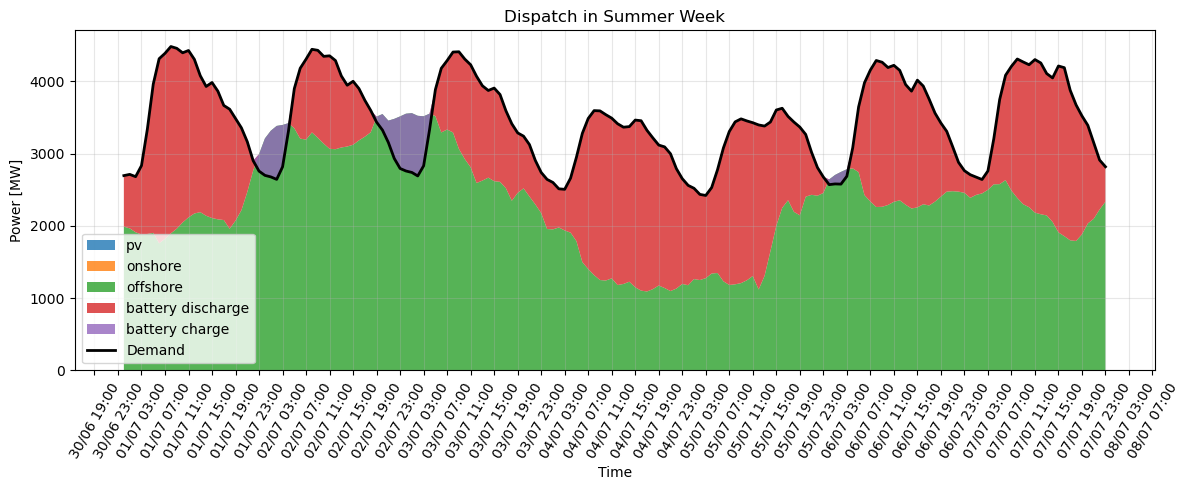

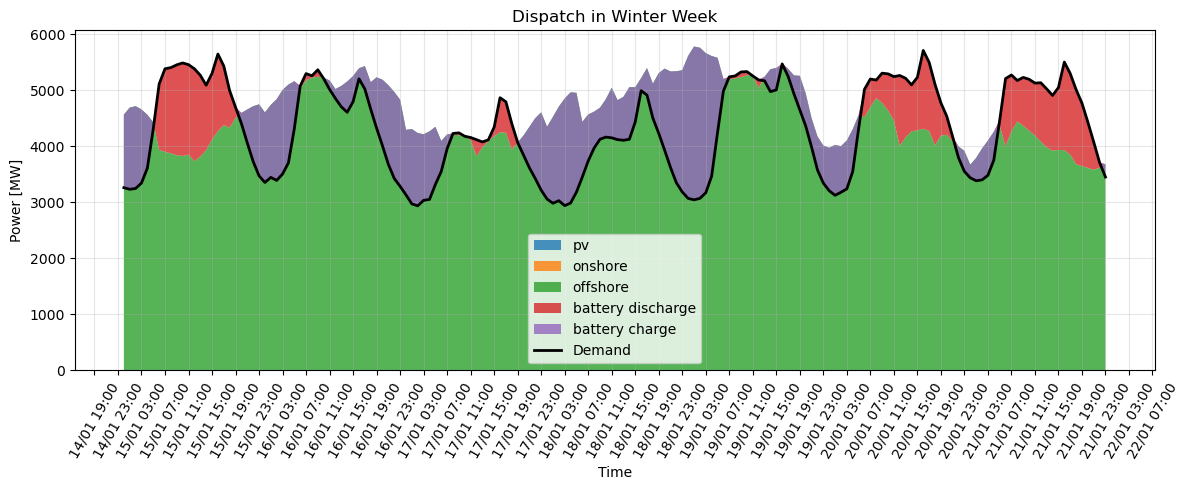

In [45]:
# Plots part A
# Martin

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
dispatch_df = pd.DataFrame(index=work_df.index)
dispatch_df["demand"] = work_df["demand"].values
dispatch_df["pv"] = g_pv.solution.to_pandas().values
dispatch_df["onshore"] = g_onshore_wind.solution.to_pandas().values
dispatch_df["offshore"] = g_offshore_wind.solution.to_pandas().values
dispatch_df["battery_discharge"] = p_discharge.solution.to_pandas().values
dispatch_df["battery_charge"] = -p_charge.solution.to_pandas().values

summer_week = dispatch_df.loc["2015-07-01":"2015-07-07 23:00"].copy()

x = summer_week.index

fig, ax = plt.subplots(figsize=(12, 5))

# Stacked generation
ax.stackplot(
    x,
    summer_week["pv"],
    summer_week["onshore"],
    summer_week["offshore"],
    summer_week["battery_discharge"],
    summer_week["battery_charge"],
    labels=["pv", "onshore", "offshore", "battery discharge", "battery charge"],
    alpha=0.8
)

# Demand line
ax.plot(x, summer_week["demand"], color="black", linewidth=2, label="Demand")

# Tick locations and formatting
ax.xaxis.set_major_locator(mdates.HourLocator(interval=4))   # change to 6 for more ticks
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %H:%M"))

ax.tick_params(axis="x", rotation=60)

ax.set_title("Dispatch in Summer Week")
ax.set_xlabel("Time")
ax.set_ylabel("Power [MW]")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

winter_week = dispatch_df.loc["2015-01-15":"2015-01-21 23:00"].copy()

x = winter_week.index

fig, ax = plt.subplots(figsize=(12, 5))

ax.stackplot(
    x,
    winter_week["pv"],
    winter_week["onshore"],
    winter_week["offshore"],
    winter_week["battery_discharge"],
    winter_week["battery_charge"],
    labels=["pv", "onshore", "offshore", "battery discharge", "battery charge"],
    alpha=0.8
)

ax.plot(x, winter_week["demand"], color="black", linewidth=2, label="Demand")

ax.xaxis.set_major_locator(mdates.HourLocator(interval=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %H:%M"))

ax.tick_params(axis="x", rotation=60)

ax.set_title("Dispatch in Winter Week")
ax.set_xlabel("Time")
ax.set_ylabel("Power [MW]")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

           capacity_MW  annual_generation_MWh  fleet_capacity_factor  \
pv        0.000000e+00           0.000000e+00               0.000000   
onshore   0.000000e+00           0.000000e+00               0.000000   
offshore  9.171085e+03           3.317905e+07               0.412990   
battery   1.404004e+06           4.332859e+06               0.000352   

          generation_share  
pv                0.000000  
onshore           0.000000  
offshore          0.884494  
battery           0.115506  


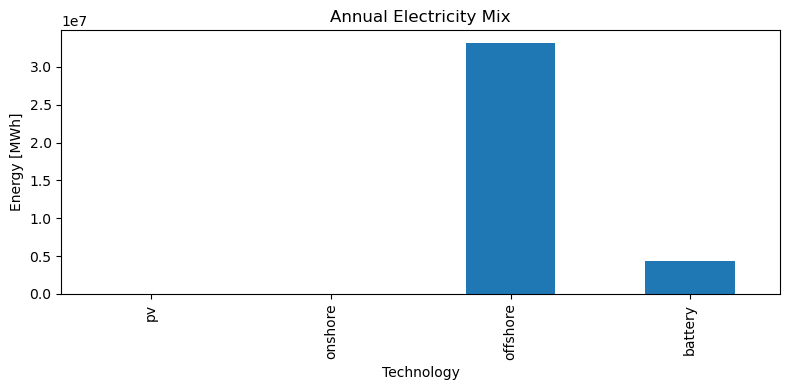

In [47]:
annual_generation = dispatch_df[["pv", "onshore", "offshore", "battery_discharge"]].sum()

summary = pd.DataFrame(index=["pv", "onshore", "offshore", "battery"])

summary["capacity_MW"] = [
    float(K_pv.solution),
    float(K_onshore_wind.solution),
    float(K_offshore_wind.solution),
    float(K_battery.solution),
]

summary["annual_generation_MWh"] = [
    annual_generation["pv"],
    annual_generation["onshore"],
    annual_generation["offshore"],
    annual_generation["battery_discharge"],
]

summary["fleet_capacity_factor"] = (
    summary["annual_generation_MWh"] / (summary["capacity_MW"] * 8760)
).replace([float("inf")], 0).fillna(0)

summary["generation_share"] = (
    summary["annual_generation_MWh"] / summary["annual_generation_MWh"].sum()
)

print(summary)

fig, ax = plt.subplots(figsize=(8, 4))
annual_generation.index = ["pv", "onshore", "offshore", "battery"]
annual_generation.plot(kind="bar", ax=ax)
ax.set_title("Annual Electricity Mix")
ax.set_ylabel("Energy [MWh]")
ax.set_xlabel("Technology")
plt.tight_layout()
plt.show()

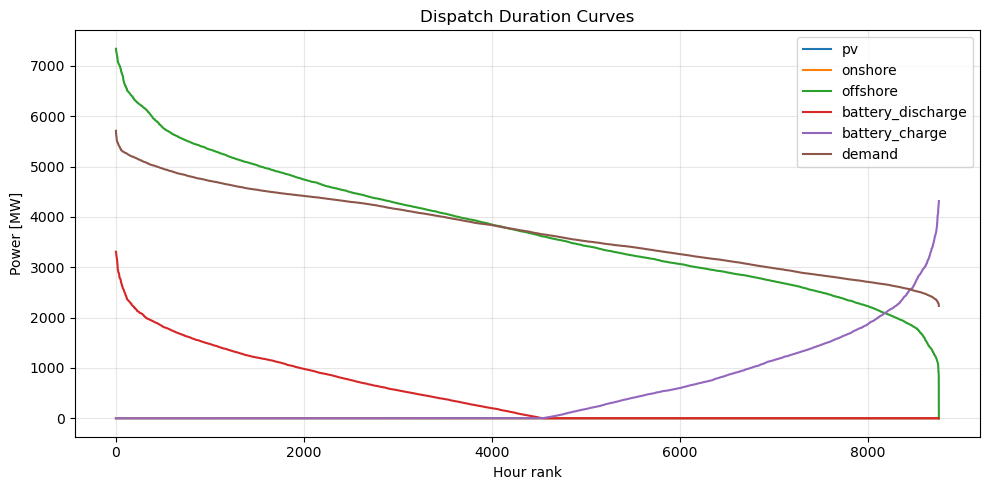

In [48]:
duration_df = pd.DataFrame({
    "pv": dispatch_df["pv"].sort_values(ascending=False).values,
    "onshore": dispatch_df["onshore"].sort_values(ascending=False).values,
    "offshore": dispatch_df["offshore"].sort_values(ascending=False).values,
    "battery_discharge": dispatch_df["battery_discharge"].sort_values(ascending=False).values,
    "battery_charge": -dispatch_df["battery_charge"].sort_values(ascending=False).values,
    "demand": dispatch_df["demand"].sort_values(ascending=False).values,
})

fig, ax = plt.subplots(figsize=(10, 5))

duration_df.plot(ax=ax)

ax.set_title("Dispatch Duration Curves")
ax.set_xlabel("Hour rank")
ax.set_ylabel("Power [MW]")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Part B

In [ ]:
import pypsa
import pandas as pd
import numpy as np

# ----------------------------
# Create time snapshots
# ----------------------------
hours = pd.date_range("2025-01-01 00:00", periods=24, freq="h")

# Demand profile
load = pd.Series(100.0, index=hours)

# ----------------------------
# Weather year A
# ----------------------------
wind_cf_A = pd.Series(
[0.45,0.42,0.40,0.38,0.35,0.33,0.30,0.32,0.36,0.40,0.43,0.46,
0.48,0.50,0.47,0.44,0.41,0.39,0.37,0.36,0.38,0.41,0.44,0.46],
index=hours)

solar_cf_A = pd.Series(
[0,0,0,0,0,0.02,0.10,0.25,0.45,0.60,0.70,0.75,
0.72,0.65,0.50,0.30,0.12,0.02,0,0,0,0,0,0],
index=hours)

# ----------------------------
# Weather year B
# ----------------------------
wind_cf_B = pd.Series(
[0.22,0.20,0.18,0.17,0.16,0.15,0.14,0.16,0.18,0.20,0.22,0.24,
0.26,0.28,0.27,0.25,0.23,0.22,0.21,0.20,0.21,0.22,0.23,0.24],
index=hours)

solar_cf_B = pd.Series(
[0,0,0,0,0,0.05,0.18,0.35,0.55,0.72,0.82,0.88,
0.84,0.76,0.60,0.40,0.20,0.06,0,0,0,0,0,0],
index=hours)

# ----------------------------
# Model function
# ----------------------------
def run_model(wind_cf, solar_cf, label):

    n = pypsa.Network()
    n.set_snapshots(hours)

    n.add("Bus", "electricity", carrier="electricity")

    n.add("Load",
          "demand",
          bus="electricity",
          p_set=load)

    n.add("Generator",
          "wind",
          bus="electricity",
          p_max_pu=wind_cf,
          capital_cost=600,
          marginal_cost=0,
          p_nom_extendable=True)

    n.add("Generator",
          "solar",
          bus="electricity",
          p_max_pu=solar_cf,
          capital_cost=400,
          marginal_cost=0,
          p_nom_extendable=True)

    n.add("Generator",
          "gas",
          bus="electricity",
          p_max_pu=1,
          capital_cost=800,
          marginal_cost=70,
          p_nom_extendable=True)

    n.optimize()

    result = {
        "year": label,
        "avg_wind_cf": wind_cf.mean(),
        "avg_solar_cf": solar_cf.mean(),
        "wind_capacity": n.generators.at["wind","p_nom_opt"],
        "solar_capacity": n.generators.at["solar","p_nom_opt"],
        "gas_capacity": n.generators.at["gas","p_nom_opt"]
    }

    return n, result


# ----------------------------
# Run both weather years
# ----------------------------
nA, resA = run_model(wind_cf_A, solar_cf_A, "Year A")
nB, resB = run_model(wind_cf_B, solar_cf_B, "Year B")

results = pd.DataFrame([resA,resB])

print(results)

In [ ]:
import matplotlib.pyplot as plt

# ----------------------------
# Capacity factors
# ----------------------------
cf_table = results[["year","avg_wind_cf","avg_solar_cf"]].set_index("year")

cf_table.plot(kind="bar")
plt.title("Average renewable capacity factors by year")
plt.ylabel("Capacity factor")
plt.show()


# ----------------------------
# Installed capacities
# ----------------------------
capacity_table = results[
["year","wind_capacity","solar_capacity","gas_capacity"]
].set_index("year")

capacity_table.plot(kind="bar")
plt.title("Optimized installed capacities")
plt.ylabel("MW")
plt.show()


# ----------------------------
# Dispatch plots
# ----------------------------
dispatch_A = nA.generators_t.p[["wind","solar","gas"]]
dispatch_A.plot()
plt.title("Dispatch Year A")
plt.ylabel("MW")
plt.show()

dispatch_B = nB.generators_t.p[["wind","solar","gas"]]
dispatch_B.plot()
plt.title("Dispatch Year B")
plt.ylabel("MW")
plt.show()

### Part C

In [ ]:
# Code part C

In [ ]:
# Plots part C

### Part D

In [ ]:
# Code part D

In [ ]:
# Plots part D

### Part E